# 5. Deterministic Self-Similar Fractal Curve (Koch Curve)

**Computer Graphics LAB — Python Implementation**

## Problem Explanation


A deterministic self-similar fractal is generated by repeatedly applying the same geometric rule.
The Koch curve starts from one line segment. Each segment is divided into three parts and the
middle part is replaced by two segments that form a triangular bump.


    **বাংলায় সহজভাবে:**  
    একই geometric rule বারবার repeat করলে self-similar shape তৈরি হয়। এখানে Koch curve ব্যবহার করা হয়েছে, যা deterministic fractal-এর classic example।

## Algorithm Steps

1. Start with one line segment.
2. Divide the segment into three equal parts.
3. Create an equilateral-triangle-style peak on the middle third.
4. Replace the original segment by four smaller segments.
5. Repeat the same rule recursively for the desired depth.

## Python Solution

নিচের code cell run করলে algorithm-এর result graphically দেখা যাবে।
Sample input দেওয়া আছে; চাইলে নিজের value বসিয়ে পরিবর্তন করতে পারবেন।

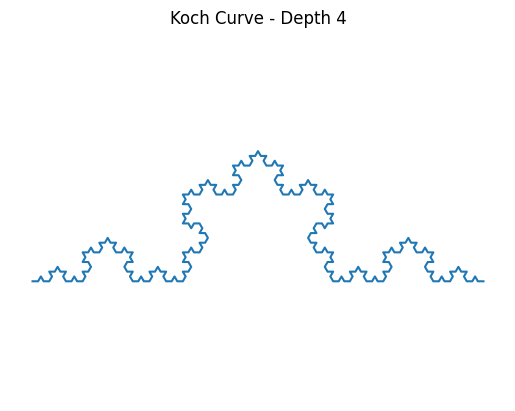

In [1]:
import matplotlib.pyplot as plt
import math

def koch_curve(p1, p2, depth):
    if depth == 0:
        return [p1, p2]

    x1, y1 = p1
    x2, y2 = p2

    # Points at 1/3 and 2/3 of the segment
    a = (x1 + (x2 - x1) / 3, y1 + (y2 - y1) / 3)
    b = (x1 + 2 * (x2 - x1) / 3, y1 + 2 * (y2 - y1) / 3)

    # Rotate vector AB by 60 degrees to create the peak
    vx = b[0] - a[0]
    vy = b[1] - a[1]

    angle = math.radians(60)
    peak = (
        a[0] + vx * math.cos(angle) - vy * math.sin(angle),
        a[1] + vx * math.sin(angle) + vy * math.cos(angle)
    )

    part1 = koch_curve(p1, a, depth - 1)
    part2 = koch_curve(a, peak, depth - 1)
    part3 = koch_curve(peak, b, depth - 1)
    part4 = koch_curve(b, p2, depth - 1)

    return part1[:-1] + part2[:-1] + part3[:-1] + part4

# Sample
start = (0, 0)
end = (9, 0)
depth = 4

points = koch_curve(start, end, depth)

x = [p[0] for p in points]
y = [p[1] for p in points]

plt.plot(x, y)
plt.title(f"Koch Curve - Depth {depth}")
plt.axis("equal")
plt.axis("off")
plt.show()

## What to Observe

- Code-এর শুরুতে sample input দেওয়া আছে।
- Output graph-এ original points/shape এবং final result দেখা যাবে।
- Viva-তে মূল idea, formula/decision rule, এবং algorithm-এর purpose বলতে পারলেই যথেষ্ট।